In [7]:
from torchvision import transforms, utils
from torchvision.utils import save_image
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F
from random import randint
import torch.nn as nn
from utils import Config, create_ckpt_dir, save_ckpt, load_ckpt, to_items
from PIL import Image
from dataset import InitDataset
from glob import glob
import oyaml as yaml
import numpy as np
import datetime
import random
import torch
from pconv import PConvLayer, PartialConvolution
from loss import InpaintingLoss, VGG16FeatureExtractor
import matplotlib.pyplot as plt
import os
import cv2
import warnings
warnings.filterwarnings("ignore")

In [8]:
from trainer import Trainer
from pconv_u_net import PConvUNet
from dataset import InitDataset, MaskGenerator

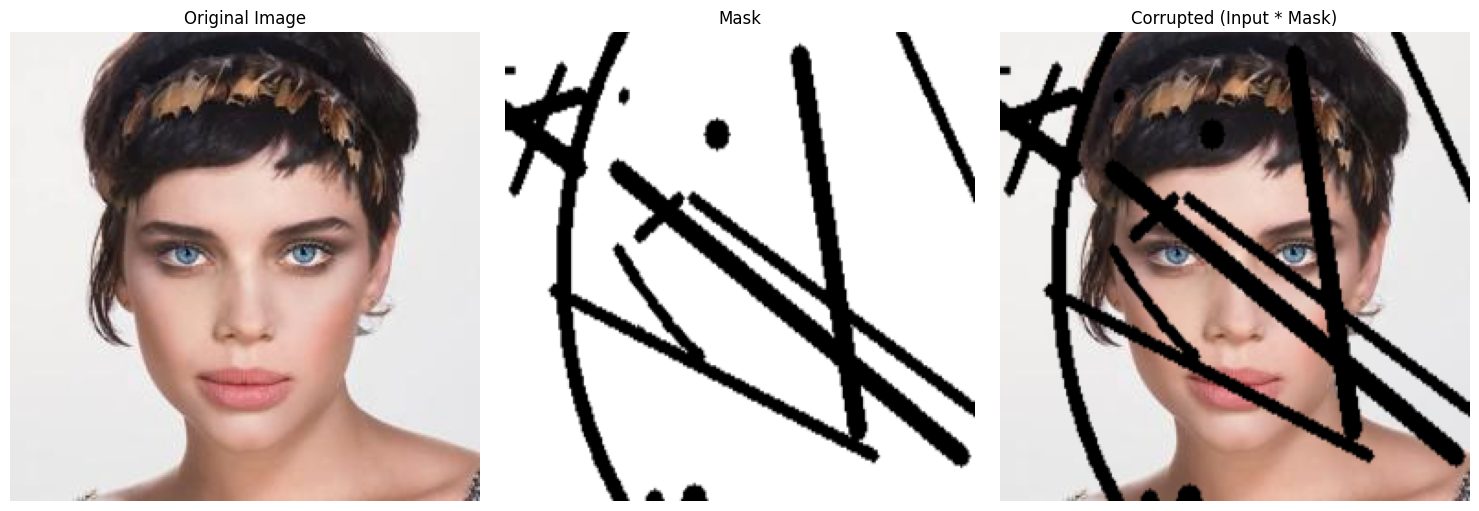

In [9]:
img_tf = transforms.Compose([
            transforms.ToTensor()
            ])

mask_tf = transforms.Compose([
            transforms.RandomResizedCrop(256),
            transforms.ToTensor()
            ])

data = InitDataset('./data_new', img_tf, mask_tf)
# print(data.__len__())
corrupted_img, mask, original_img = data[0]

corrupted_img_np = corrupted_img.permute(1, 2, 0).numpy()
original_img_np = original_img.permute(1, 2, 0).numpy()
mask_np = mask.permute(1, 2, 0).numpy()
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(original_img_np)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(mask_np)
axs[1].set_title("Mask")
axs[1].axis("off")

axs[2].imshow(corrupted_img_np)
axs[2].set_title("Corrupted (Input * Mask)")
axs[2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
config = Config("./config.yml")
config.ckpt = create_ckpt_dir()

In [11]:
img_tf = transforms.Compose([
            transforms.ToTensor()
            ])

mask_tf = transforms.Compose([
            transforms.RandomResizedCrop(256),
            transforms.ToTensor()
            ])

dataset_val = InitDataset(config.data_root,
                      img_tf,
                      mask_tf,
                      data="test")

dataset_train = InitDataset(config.data_root,
                        img_tf,
                        mask_tf,
                        data="train")

In [13]:
device = torch.device("cuda:{}".format(config.cuda_id)
                      if torch.cuda.is_available() else "cpu")

model = PConvUNet(finetune=config.finetune,
                  layer_size=config.layer_size)

if config.finetune:
    model.load_state_dict(torch.load(config.finetune)['model'])
model.to(device)

criterion = InpaintingLoss(VGG16FeatureExtractor(),
                            tv_loss=config.tv_loss).to(device)

lr = config.finetune_lr if config.finetune else config.initial_lr
if config.optim == "Adam":
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                        model.parameters()),
                                    lr=lr,
                                    weight_decay=config.weight_decay)
elif config.optim == "SGD":
    optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad,
                                        model.parameters()),
                                lr=lr,
                                momentum=config.momentum,
                                weight_decay=config.weight_decay)


In [10]:
# start_iter = 0
# trainer = Trainer(start_iter, config, device, model, dataset_train,
#                     dataset_val, criterion)
# last_saved_model, losses = trainer.iterate()

Loading PreTrained Model(trained on kaggle by us) to predict unmasked image on large masks

In [11]:
start_iter = 84000
ckpt_dir = "./ckpt/models"
ckpt_path = os.path.join(ckpt_dir, f"{start_iter}.pth")
ckpt_dict = torch.load(ckpt_path, map_location="cpu")
n_iter = load_ckpt(ckpt_path, [("model", model)], [("optimizer", optimizer)])
print(f"Loaded checkpoint from {ckpt_path}, resuming from iteration {n_iter}")

# start_iter = n_iter
# trainer = Trainer(start_iter, config, device, model, dataset_train,
#                     dataset_val, criterion, optimizer)
# trainer.iterate()

Loaded checkpoint from ./ckpt/models/84000.pth, resuming from iteration 84000


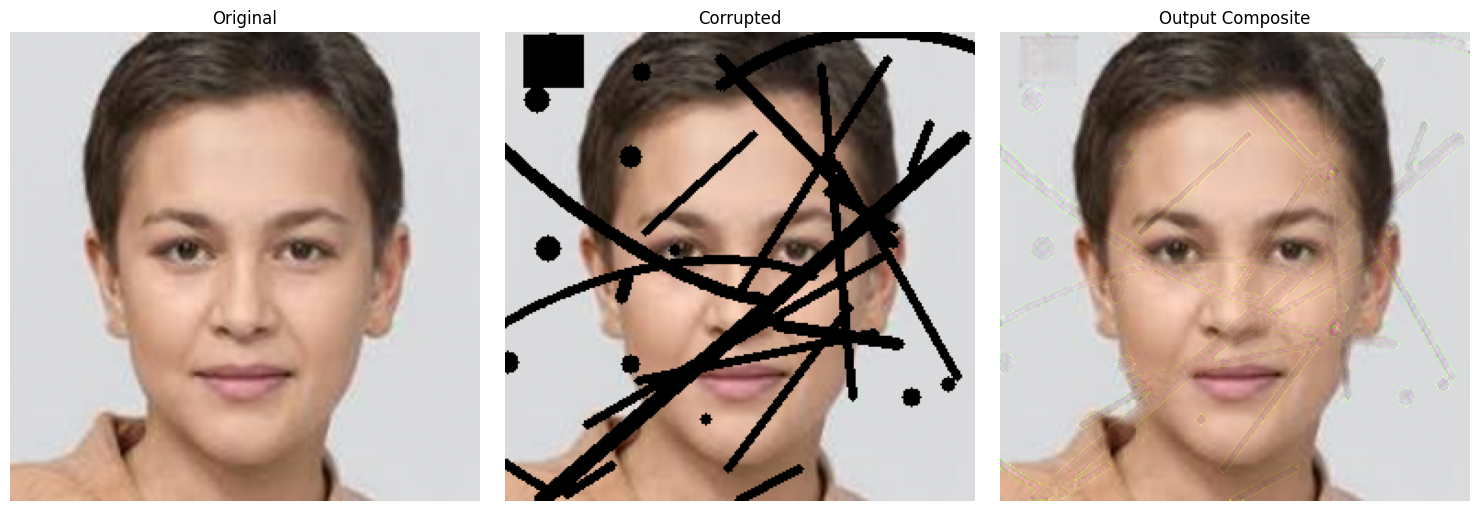

In [14]:
import torchvision.transforms as T

img = Image.open('./sample.jpg').convert('RGB').resize((256, 256))

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])
input_tensor = transform(img).unsqueeze(0).to(device)

def random_mask(size=(256, 256), hole_size=(50, 100)):
    mask_gen = MaskGenerator(*size)
    mask_np = mask_gen._generate_mask()

    mask_gray = mask_np[:, :, 0]

    mask_tensor = torch.from_numpy(mask_gray).float()
    mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)

    mask_tensor = mask_tensor.expand(1, 3, *size)
    return mask_tensor.to(device)


mask_tensor = random_mask()

corrupted_tensor = input_tensor * mask_tensor

model.eval()
with torch.no_grad():
    output_tensor, _ = model(corrupted_tensor, mask_tensor)

output_comp = mask_tensor * input_tensor + (1 - mask_tensor) * output_tensor

def imshow_tensor(tensor, title):
    img = tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img = np.clip(img, 0, 1)
    if img.shape[2] == 1:
        img = img[:, :, 0]
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
imshow_tensor(input_tensor, "Original")

plt.subplot(1, 3, 2)
imshow_tensor(corrupted_tensor, "Corrupted")

plt.subplot(1, 3, 3)
imshow_tensor(output_comp,
              "Output Composite")
plt.tight_layout()
plt.show()


Loading Pre-Trained model to increase resolution of the image(trained on kaggle)

In [15]:
start_iter = "super_res"
ckpt_dir = "./ckpt/models"
ckpt_path = os.path.join(ckpt_dir, f"{start_iter}.pth")
ckpt_dict = torch.load(ckpt_path, map_location="cpu")
n_iter = load_ckpt(ckpt_path, [("model", model)], [("optimizer", optimizer)])
print(f"✅ Loaded checkpoint from {ckpt_path}, resuming from iteration {n_iter}")

✅ Loaded checkpoint from ./ckpt/models/super_res.pth, resuming from iteration 4000


In [16]:
def generate_mask(K=4,C=3,H=128,W=128):
    KH, KW = K * H, K * W
    offset = K // 2


    mask = torch.zeros((C, KH, KW), dtype=torch.uint8, device='cuda' if torch.cuda.is_available() else 'cpu')

    for x in range(H):
        for y in range(W):
            new_x = K * x + offset
            new_y = K * y + offset
            if new_x < KH and new_y < KW:

                mask[:, new_x, new_y] = 1

    return mask

# my_mask = generate_mask(K=2)
# my_mask = my_mask.permute(1, 2, 0).cpu().numpy()  # Convert from (C, H, W) → (H, W, C)
#
# # Save
# cv2.imwrite('./data_new/0.png', my_mask * 255)  # Multiply by 255 to make 1s visible as white

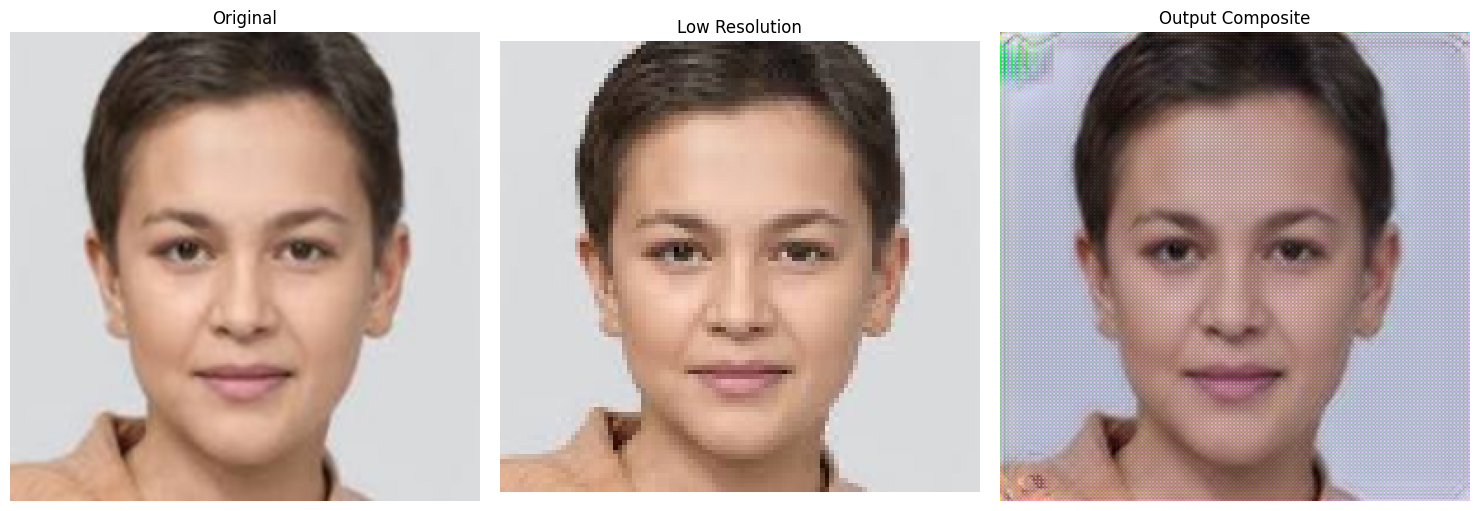

In [18]:
import torchvision.transforms as T

img = Image.open('./sample.jpg').convert('RGB')
img2=np.array(img)
downsampled = img2[::2, ::2, :]

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])
input_tensor = transform(img).unsqueeze(0).to(device)
my_mask1 = cv2.imread('./data_new/0.png')
my_mask = torch.from_numpy(my_mask1).permute(2, 0, 1).float() / 255.0  # Normalize
mask_tensor = my_mask.unsqueeze(0).to(device)

corrupted_tensor = input_tensor * mask_tensor

model.eval()
with torch.no_grad():
    output_tensor, _ = model(corrupted_tensor, mask_tensor)

# Composite: paste prediction into masked region
output_comp = mask_tensor * input_tensor + (1 - mask_tensor) * output_tensor

# Visualize
def imshow_tensor(tensor, title):
    img = tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img = np.clip(img, 0, 1)
    if img.shape[2] == 1:
        img = img[:, :, 0]
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
imshow_tensor(input_tensor, "Original")

plt.subplot(1, 3, 2)
plt.imshow(downsampled)
plt.title("Low Resolution")
plt.axis('off')

# plt.subplot(1, 3, 3)
# imshow_tensor(corrupted_tensor, "Corrupted")

plt.subplot(1, 3, 3)
imshow_tensor(output_comp, "Output Composite")
plt.tight_layout()
plt.show()


Comparisions between models with full loss, no style loss and no perceptual loss

In [14]:
model_normal = PConvUNet(finetune=config.finetune,
                  layer_size=config.layer_size)
if config.finetune:
    model_normal.load_state_dict(torch.load(config.finetune)['model'])
model_normal.to(device)
lr = config.finetune_lr if config.finetune else config.initial_lr
if config.optim == "Adam":
    optimizer_normal = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                        model_normal.parameters()),
                                    lr=lr,
                                    weight_decay=config.weight_decay)
elif config.optim == "SGD":
    optimizer_normal = torch.optim.SGD(filter(lambda p: p.requires_grad,
                                        model_normal.parameters()),
                                lr=lr,
                                momentum=config.momentum,
                                weight_decay=config.weight_decay)

model_nostyle = PConvUNet(finetune=config.finetune,
                  layer_size=config.layer_size)
if config.finetune:
    model_nostyle.load_state_dict(torch.load(config.finetune)['model'])
model_nostyle.to(device)
lr = config.finetune_lr if config.finetune else config.initial_lr
if config.optim == "Adam":
    optimizer_nostyle = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                        model_nostyle.parameters()),
                                    lr=lr,
                                    weight_decay=config.weight_decay)
elif config.optim == "SGD":
    optimizer_nostyle = torch.optim.SGD(filter(lambda p: p.requires_grad,
                                        model_nostyle.parameters()),
                                lr=lr,
                                momentum=config.momentum,
                                weight_decay=config.weight_decay)

model_noperc = PConvUNet(finetune=config.finetune,
                  layer_size=config.layer_size)
if config.finetune:
    model_noperc.load_state_dict(torch.load(config.finetune)['model'])
model_noperc.to(device)
lr = config.finetune_lr if config.finetune else config.initial_lr
if config.optim == "Adam":
    optimizer_noperc = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                        model_noperc.parameters()),
                                    lr=lr,
                                    weight_decay=config.weight_decay)
elif config.optim == "SGD":
    optimizer_noperc = torch.optim.SGD(filter(lambda p: p.requires_grad,
                                        model_noperc.parameters()),
                                lr=lr,
                                momentum=config.momentum,
                                weight_decay=config.weight_decay)


In [16]:
load_ckpt("./ckpt/models/normal.pth", [("model", model_normal)], [("optimizer", optimizer_normal)])
load_ckpt("./ckpt/models/no_style.pth", [("model", model_nostyle)], [("optimizer", optimizer_nostyle)])
load_ckpt("./ckpt/models/no_perc.pth", [("model", model_noperc)], [("optimizer", optimizer_noperc)])

6000

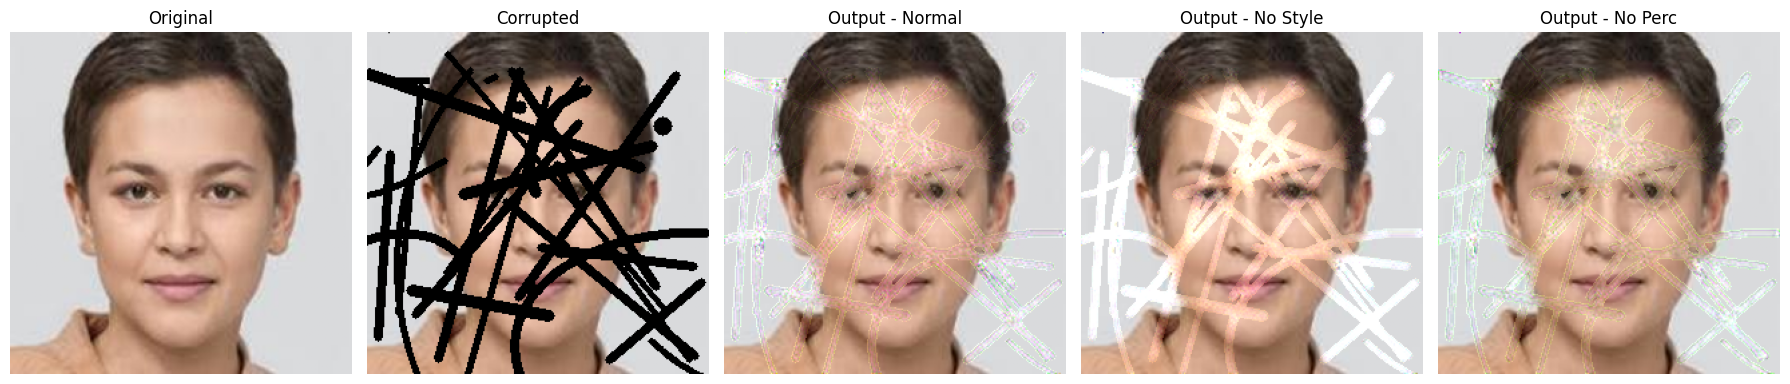

In [18]:
import torchvision.transforms as T

# Load and preprocess image
img = Image.open('./sample.jpg').convert('RGB').resize((256, 256))
transform = T.Compose([
    T.ToTensor()
])
input_tensor = transform(img).unsqueeze(0).to(device)

# Generate random mask
def random_mask(size=(256, 256)):
    mask_gen = MaskGenerator(*size)
    mask_np = mask_gen._generate_mask()
    mask_gray = mask_np[:, :, 0]
    mask_tensor = torch.from_numpy(mask_gray).float().unsqueeze(0).unsqueeze(0)
    mask_tensor = mask_tensor.expand(1, 3, *size)
    return mask_tensor.to(device)

mask_tensor = random_mask()
corrupted_tensor = input_tensor * mask_tensor

# Inference helper
def get_output(model):
    model.eval()
    with torch.no_grad():
        output_tensor, _ = model(corrupted_tensor, mask_tensor)
        output_comp = mask_tensor * input_tensor + (1 - mask_tensor) * output_tensor
    return output_comp

# Run all models
output_normal = get_output(model_normal)
output_nostyle = get_output(model_nostyle)
output_noperc = get_output(model_noperc)

# Display helper
def imshow_tensor(tensor, title):
    img = tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img = np.clip(img, 0, 1)
    if img.shape[2] == 1:
        img = img[:, :, 0]
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# Plot all results
plt.figure(figsize=(18, 6))

plt.subplot(1, 5, 1)
imshow_tensor(input_tensor, "Original")

plt.subplot(1, 5, 2)
imshow_tensor(corrupted_tensor, "Corrupted")

plt.subplot(1, 5, 3)
imshow_tensor(output_normal, "Output - Normal")

plt.subplot(1, 5, 4)
imshow_tensor(output_nostyle, "Output - No Style")

plt.subplot(1, 5, 5)
imshow_tensor(output_noperc, "Output - No Perc")

plt.tight_layout()
plt.show()
